In [2]:
#Cxt A vs B number of events - revision
import pandas as pd
# Load your exported CSV
df = pd.read_csv(r"/Volumes/rkc_ramirezlab/Home/rsenne/dCA1_Clean_Data/revision_analysis/Figure3_Recall/num_events_Fig3/Num_Detected_Events.csv")
df

,Context,Num_Events,Mouse
0,CxtA,2,astroF10
1,CxtA,3,astroF3
2,CxtA,3,astroF5
3,CxtA,2,astroF6
4,CxtA,2,astroF7
5,CxtA,2,astroF8
6,CxtA,4,astroF9
7,CxtA,6,astroM10
8,CxtA,4,astroM3
9,CxtA,3,astroM4


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_76675/2536894569.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(
/Users/suthardr/opt/anaconda3/envs/dCA1_Paper/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/suthardr/opt/anaconda3/envs/dCA1_Paper/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


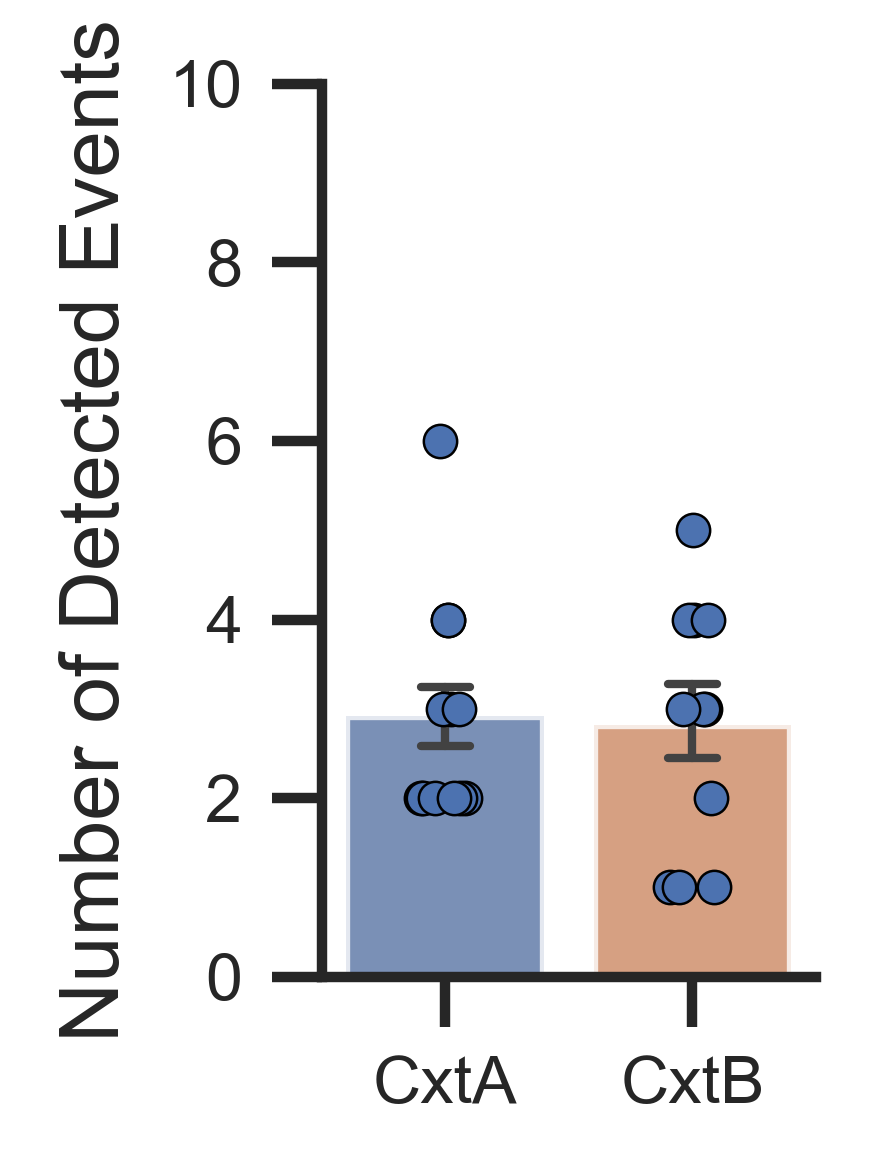

(<Figure size 900x1200 with 1 Axes>,
 <Axes: ylabel='Number of Detected Events'>)

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
def plot_num_events(df, title="", save_path=None):
    sns.set(style="ticks", font="Arial")
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(1.5, 2), dpi=600)

    # Barplot — assign color list manually using palette override
    sns.barplot(
        x='Context', y='Num_Events', data=df,
        ci=68, capsize=.2, errwidth=1,
        alpha=0.8, ax=ax
    )

    # Stripplot — black dots on top of each bar
    sns.stripplot(
        x='Context', y='Num_Events', data=df,
        jitter=True, linewidth=0.3, edgecolor='black',
        size=4, ax=ax
    )

    ax.legend_.remove() if ax.legend_ else None
    ax.set_ylabel('Number of Detected Events', fontsize=10)
    ax.set_xlabel('', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(0, 10)
    ax.set_title(title, fontsize=10, pad=10)
    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax


plot_num_events(df, save_path='/Users/suthardr/Desktop/num_events_Fig3.svg')


In [4]:
df

,Context,Num_Events,Mouse
0,CxtA,2,astroF10
1,CxtA,3,astroF3
2,CxtA,3,astroF5
3,CxtA,2,astroF6
4,CxtA,2,astroF7
5,CxtA,2,astroF8
6,CxtA,4,astroF9
7,CxtA,6,astroM10
8,CxtA,4,astroM3
9,CxtA,3,astroM4


In [5]:
import statsmodels.formula.api as smf

model = smf.mixedlm("Num_Events ~ Context", data=df, groups=df["Mouse"])
result = model.fit()

print(result.summary())


          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: Num_Events
No. Observations:   23      Method:             REML      
No. Groups:         15      Scale:              0.8661    
Min. group size:    1       Log-Likelihood:     -36.6823  
Max. group size:    2       Converged:          Yes       
Mean group size:    1.5                                   
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        2.984    0.367  8.140 0.000  2.265  3.702
Context[T.CxtB] -0.206    0.425 -0.485 0.628 -1.039  0.627
Group Var        0.802    0.817                           

